# Phase 4 (Partial) — SHAP Drift Analysis on Static GCN
**Purpose:** Compute time-indexed SHAP values across 4 windows and detect concept drift using Kendall τ rank correlation.  
**Model:** Static GCN (trained in Phase 2)  
**Dataset:** Elliptic Bitcoin — 49 snapshots  

### What this notebook produces
1. SHAP feature importance rankings per time window  
2. Side-by-side SHAP bar charts (W1 vs W4) — shows which features changed  
3. Kendall τ across windows — quantifies drift  
4. T43 prediction table — shows false negatives at shutdown  
5. All outputs saved to disk — never run live during demo  

### Time windows
| Window | Snapshots | Indices |
|--------|-----------|----------|
| W1 | T1  – T10 | 0  – 9  |
| W2 | T11 – T20 | 10 – 19 |
| W3 | T21 – T30 | 20 – 29 |
| W4 | T31 – T49 | 30 – 48 |

---
## Cell 1 — Install Dependencies

In [ ]:
import subprocess, sys, torch

# Detect actual CUDA version from PyTorch build
torch_version = torch.__version__.split('+')[0]

# Extract cuda version from torch build string e.g. '2.1.0+cu128' → 'cu128'
build_string = torch.__version__
if 'cu' in build_string:
    cuda_version = 'cu' + build_string.split('cu')[-1]
elif 'rocm' in build_string:
    cuda_version = 'rocm' + build_string.split('rocm')[-1]
else:
    cuda_version = 'cpu'

print(f'PyTorch version : {torch.__version__}')
print(f'Detected CUDA   : {cuda_version}')
print(f'Using wheel URL : https://data.pyg.org/whl/torch-{torch_version}+{cuda_version}.html')

# PyTorch Geometric
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', 'torch-geometric'
])

# Scatter and Sparse with correct CUDA version
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install',
    'torch-scatter', 'torch-sparse',
    '-f', f'https://data.pyg.org/whl/torch-{torch_version}+{cuda_version}.html'
])

subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       'scikit-learn', 'matplotlib', 'numpy', 'shap'])

print('All libraries installed.')

PyTorch version : 2.10.0+cpu
Detected CUDA   : cpu
Using wheel URL : https://data.pyg.org/whl/torch-2.10.0+cpu.html
All libraries installed.


---
## Cell 2 — Imports & Global Config

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import shap
from scipy.stats import kendalltau
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Paths ─────────────────────────────────────────────────────────────────────
# Adjust BASE_DIR for Google Colab:
BASE_DIR      = '/content/drive/MyDrive/Capstone/AML Code'
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
FIGURES_DIR   = os.path.join(BASE_DIR, 'figures')
SHAP_DIR      = os.path.join(BASE_DIR, 'data', 'shap')

for d in [FIGURES_DIR, SHAP_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
SEED          = 42
IN_CHANNELS   = 165
HIDDEN1       = 64
HIDDEN2       = 32
DROPOUT       = 0.5
SHUTDOWN_STEP = 43
NUM_FEATURES  = 165
feature_names = [f'feat_{i}' for i in range(NUM_FEATURES)]

# ── SHAP config ───────────────────────────────────────────────────────────────
N_BACKGROUND           = 100   # licit background samples per window
N_SHAP_SAMPLES         = 200 #50   # KernelSHAP nsamples
TOP_K                  = 10    # top-K features for Kendall τ ranking
TAU_THRESHOLD          = 0.70  # drift flag threshold
MAX_ILLICIT_PER_WINDOW = 1600 #20   # max illicit nodes to run SHAP on per window

# ── Time windows (0-based snapshot indices) ───────────────────────────────────
WINDOWS = {
    'W1': list(range(0,  10)),   # T1  – T10
    'W2': list(range(10, 20)),   # T11 – T20
    'W3': list(range(20, 30)),   # T21 – T30
    'W4': list(range(30, 49)),   # T31 – T49  (contains T43 shutdown)
}

torch.manual_seed(SEED)
np.random.seed(SEED)

print('Config loaded.')
for w, idx in WINDOWS.items():
    t_start = idx[0] + 1
    t_end   = idx[-1] + 1
    print(f'  {w}: T{t_start}–T{t_end}  ({len(idx)} snapshots,  indices {idx[0]}–{idx[-1]})')

Config loaded.
  W1: T1–T10  (10 snapshots,  indices 0–9)
  W2: T11–T20  (10 snapshots,  indices 10–19)
  W3: T21–T30  (10 snapshots,  indices 20–29)
  W4: T31–T49  (19 snapshots,  indices 30–48)


---
## Cell 3 — Device Setup

In [ ]:
# SHAP runs on CPU regardless — move model to CPU for SHAP
# GPU is used only for predictions outside SHAP
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Primary device : {device}')
print(f'SHAP device    : cpu  (KernelSHAP always runs on CPU)')

Primary device : cpu
SHAP device    : cpu  (KernelSHAP always runs on CPU)


---
## Cell 4 — Load Snapshots

In [ ]:
snapshots_path = os.path.join(PROCESSED_DIR, 'snapshots.pt')
snapshots = torch.load(snapshots_path, weights_only=False)

print(f'Snapshots loaded : {len(snapshots)}')
print(f'Feature dim      : {snapshots[0].x.shape[1]}')

# Quick window summary
print()
print('Window composition:')
for w, idx in WINDOWS.items():
    snaps      = [snapshots[i] for i in idx]
    total_nodes   = sum(s.num_nodes for s in snaps)
    total_illicit = int(sum(s.y.sum().item() for s in snaps))
    total_licit   = total_nodes - total_illicit
    print(f'  {w}: {total_nodes:,} nodes  |  {total_illicit:,} illicit  |  {total_licit:,} licit')

Snapshots loaded : 49
Feature dim      : 165

Window composition:
  W1: 12,468 nodes  |  524 illicit  |  11,944 licit
  W2: 6,421 nodes  |  1,247 illicit  |  5,174 licit
  W3: 8,016 nodes  |  1,183 illicit  |  6,833 licit
  W4: 19,659 nodes  |  1,591 illicit  |  18,068 licit


---
## Cell 5 — Define & Load Static GCN

In [ ]:
class StaticGCN(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, hidden1=HIDDEN1,
                 hidden2=HIDDEN2, dropout=DROPOUT):
        super().__init__()
        self.conv1      = GCNConv(in_channels, hidden1)
        self.conv2      = GCNConv(hidden1, hidden2)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden2, 2)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        return self.classifier(x), x


# Load trained weights from Phase 2
model_path = os.path.join(MODELS_DIR, 'static_gcn_best.pt')
model = StaticGCN()
model.load_state_dict(
    torch.load(model_path, map_location='cpu', weights_only=True)
)
model.eval()

print(f'Static GCN loaded from : {model_path}')
print(f'Parameters             : {sum(p.numel() for p in model.parameters()):,}')

Static GCN loaded from : /content/drive/MyDrive/Capstone/AML Code/models/static_gcn_best.pt
Parameters             : 12,770


---
## Cell 6 — Build SHAP Wrapper
KernelSHAP is model-agnostic and works on tabular inputs.  
We wrap the GCN so it takes a numpy feature matrix and returns illicit probabilities.  
The edge_index is fixed per window — we are explaining **node features**, not graph structure.

In [ ]:
def make_shap_predictor(num_features=IN_CHANNELS):
    """
    Returns a function that KernelSHAP can call.
    Uses empty edge_index so node count can vary freely.
    This is correct for feature-level explanation — we are
    explaining which features drive predictions, not which edges.
    Input : numpy array of shape (N, 165)
    Output: numpy array of shape (N,) — probability of illicit
    """
    def predictor(x_numpy):
        x_tensor   = torch.tensor(x_numpy, dtype=torch.float32)
        n_nodes    = x_tensor.shape[0]
        # Empty edge_index — no edges, nodes explained independently
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        with torch.no_grad():
            logits, _ = model(x_tensor, edge_index)
            probs = torch.softmax(logits, dim=1)[:, 1]
        return probs.numpy()
    return predictor


def collect_window_data(idx_list):
    """
    Concatenate all node features and labels across snapshots in a window.
    Returns: X (numpy), y (numpy), edge_index of the last snapshot (for wrapper)
    """
    X_list, y_list = [], []
    last_edge_index = None

    for i in idx_list:
        s = snapshots[i]
        X_list.append(s.x.numpy())
        y_list.append(s.y.numpy())
        last_edge_index = s.edge_index  # edge_index from last snapshot in window

    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    return X, y, last_edge_index


print('SHAP wrapper functions defined.')
print()
print('NOTE: KernelSHAP with nsamples=200 on large windows can take 20–40 min.')
print('      Results are saved to disk after each window — safe to interrupt and resume.')

SHAP wrapper functions defined.

NOTE: KernelSHAP with nsamples=200 on large windows can take 20–40 min.
      Results are saved to disk after each window — safe to interrupt and resume.


---
## Cell 7 — Compute SHAP Values Per Window
**This is the slow cell — expect 20–40 minutes total.**  
Each window is saved immediately after completion.  
If interrupted, re-run and already-saved windows will be skipped.

In [ ]:
shap_results = {}   # window_name → dict with shap_values, X, y, importance

for window_name, idx_list in WINDOWS.items():
    save_path = os.path.join(SHAP_DIR, f'shap_{window_name}.pkl')

    # Skip if already computed
    if os.path.exists(save_path):
        print(f'{window_name}: Loading from cache → {save_path}')
        with open(save_path, 'rb') as f:
            shap_results[window_name] = pickle.load(f)
        continue

    t_start = idx_list[0] + 1
    t_end   = idx_list[-1] + 1
    print(f'{window_name} (T{t_start}–T{t_end}): Collecting data...', end=' ', flush=True)

    X, y, edge_index = collect_window_data(idx_list)

    # Separate licit (background) and illicit (foreground)
    licit_mask   = (y == 0)
    illicit_mask = (y == 1)

    X_licit   = X[licit_mask]
    X_illicit = X[illicit_mask]

    print(f'{X.shape[0]:,} nodes  ({illicit_mask.sum()} illicit  {licit_mask.sum()} licit)')

    # Sample background — N_BACKGROUND random licit nodes
    np.random.seed(SEED)
    bg_idx = np.random.choice(len(X_licit),
                               min(N_BACKGROUND, len(X_licit)),
                               replace=False)
    background = X_licit[bg_idx]

    predictor = make_shap_predictor()

    # KernelSHAP explainer
    explainer = shap.KernelExplainer(predictor, background)

    # Subsample illicit nodes
    np.random.seed(SEED)
    if len(X_illicit) > MAX_ILLICIT_PER_WINDOW:
        sample_idx       = np.random.choice(len(X_illicit),
                                             MAX_ILLICIT_PER_WINDOW,
                                             replace=False)
        X_illicit_sample = X_illicit[sample_idx]
        print(f'  Subsampled illicit : {len(X_illicit)} → {MAX_ILLICIT_PER_WINDOW}')
    else:
        X_illicit_sample = X_illicit
        print(f'  Using all {len(X_illicit)} illicit nodes (below cap of {MAX_ILLICIT_PER_WINDOW})')

    print(f'  Running KernelSHAP (nsamples={N_SHAP_SAMPLES})... ', end='', flush=True)
    shap_vals = explainer.shap_values(X_illicit_sample, nsamples=N_SHAP_SAMPLES, silent=True)

    # Global importance = mean |SHAP| across illicit nodes
    importance = np.abs(shap_vals).mean(axis=0)  # shape: (165,)

    # Ranked feature indices (most important first)
    ranked_idx = np.argsort(importance)[::-1]     # descending

    result = {
        'window'      : window_name,
        'time_range'  : f'T{t_start}–T{t_end}',
        'shap_values' : shap_vals,
        'X_illicit'   : X_illicit_sample,
        'importance'  : importance,
        'ranked_idx'  : ranked_idx,
        'top10_idx'   : ranked_idx[:TOP_K].tolist(),
        'top10_names' : [f'feat_{i}' for i in ranked_idx[:TOP_K]],
        'top10_vals'  : importance[ranked_idx[:TOP_K]].tolist(),
    }

    shap_results[window_name] = result

    with open(save_path, 'wb') as f:
        pickle.dump(result, f)

    print(f'done. Saved → {save_path}')
    print(f'  Top 5 features: {result["top10_names"][:5]}')
    print()

print('All windows complete.')

W1 (T1–T10): Collecting data... 12,468 nodes  (524 illicit  11944 licit)
  Using all 524 illicit nodes (below cap of 1600)
  Running KernelSHAP (nsamples=200)... done. Saved → /content/drive/MyDrive/Capstone/AML Code/data/shap/shap_W1.pkl
  Top 5 features: ['feat_89', 'feat_54', 'feat_52', 'feat_2', 'feat_51']

W2 (T11–T20): Collecting data... 6,421 nodes  (1247 illicit  5174 licit)
  Using all 1247 illicit nodes (below cap of 1600)
  Running KernelSHAP (nsamples=200)... done. Saved → /content/drive/MyDrive/Capstone/AML Code/data/shap/shap_W2.pkl
  Top 5 features: ['feat_54', 'feat_51', 'feat_52', 'feat_89', 'feat_79']

W3 (T21–T30): Collecting data... 8,016 nodes  (1183 illicit  6833 licit)
  Using all 1183 illicit nodes (below cap of 1600)
  Running KernelSHAP (nsamples=200)... done. Saved → /content/drive/MyDrive/Capstone/AML Code/data/shap/shap_W3.pkl
  Top 5 features: ['feat_54', 'feat_52', 'feat_51', 'feat_89', 'feat_87']

W4 (T31–T49): Collecting data... 19,659 nodes  (1591 illi

---
## Cell 8 — Print Top-10 Feature Rankings Per Window

In [ ]:
print('TOP-10 SHAP FEATURE RANKINGS PER WINDOW')
print('=' * 65)

for window_name, res in shap_results.items():
    print(f'\n{window_name} ({res["time_range"]})')
    print(f'  {"Rank":<6} {"Feature":<12} {"Mean |SHAP|"}')
    print(f'  {"-"*35}')
    for rank, (feat, val) in enumerate(
        zip(res['top10_names'], res['top10_vals']), start=1
    ):
        print(f'  {rank:<6} {feat:<12} {val:.6f}')

print()
print('NOTE: Rankings are by mean absolute SHAP value across illicit nodes.')
print('      A change in rankings across windows = model decision logic shifted.')

TOP-10 SHAP FEATURE RANKINGS PER WINDOW

W1 (T1–T10)
  Rank   Feature      Mean |SHAP|
  -----------------------------------
  1      feat_89      0.071507
  2      feat_54      0.062154
  3      feat_52      0.061986
  4      feat_2       0.058137
  5      feat_51      0.041868
  6      feat_141     0.029210
  7      feat_88      0.019507
  8      feat_114     0.018152
  9      feat_129     0.017453
  10     feat_79      0.016631

W2 (T11–T20)
  Rank   Feature      Mean |SHAP|
  -----------------------------------
  1      feat_54      0.097082
  2      feat_51      0.086063
  3      feat_52      0.084655
  4      feat_89      0.073919
  5      feat_79      0.028307
  6      feat_80      0.024857
  7      feat_141     0.023389
  8      feat_88      0.021370
  9      feat_129     0.018653
  10     feat_114     0.015582

W3 (T21–T30)
  Rank   Feature      Mean |SHAP|
  -----------------------------------
  1      feat_54      0.063169
  2      feat_52      0.056926
  3      feat_51     

---
## Cell 8.5 — Beeswarm Plots

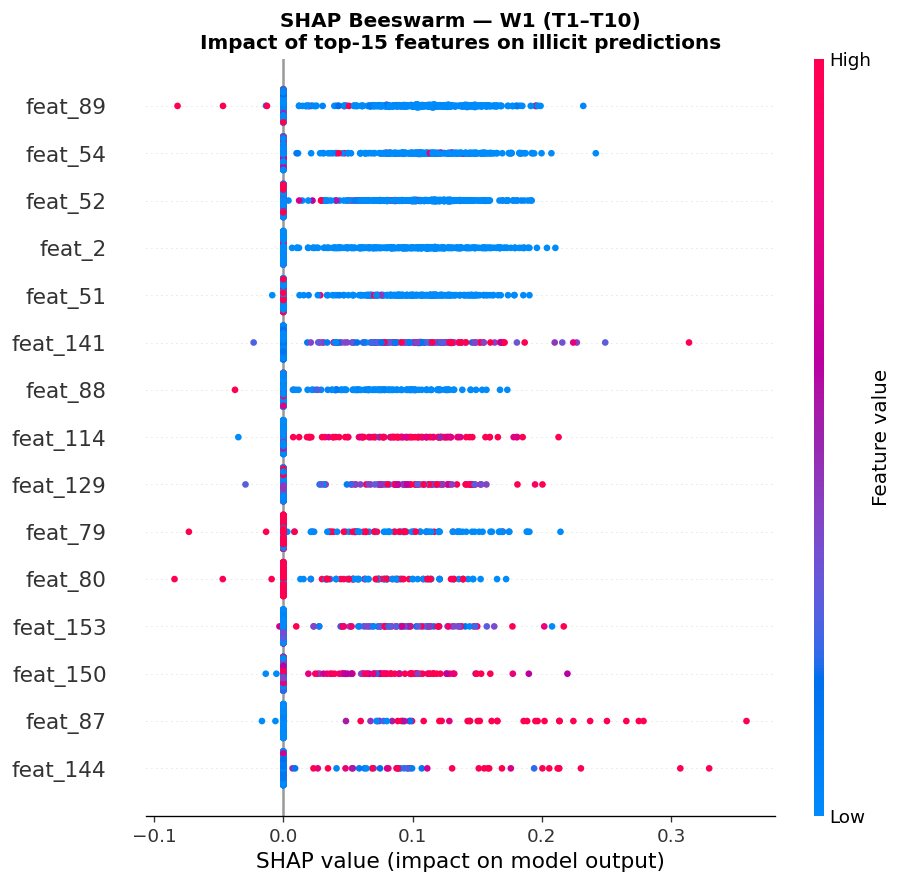

Saved → /content/drive/MyDrive/Capstone/AML Code/figures/shap_beeswarm_W1.png


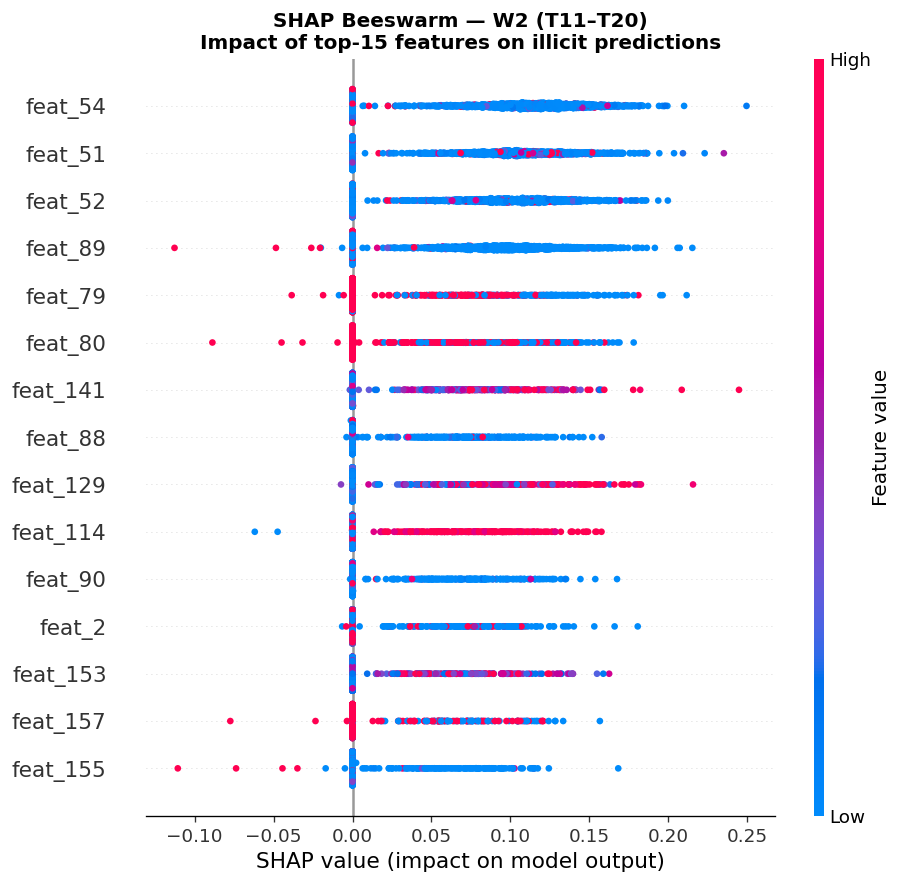

Saved → /content/drive/MyDrive/Capstone/AML Code/figures/shap_beeswarm_W2.png


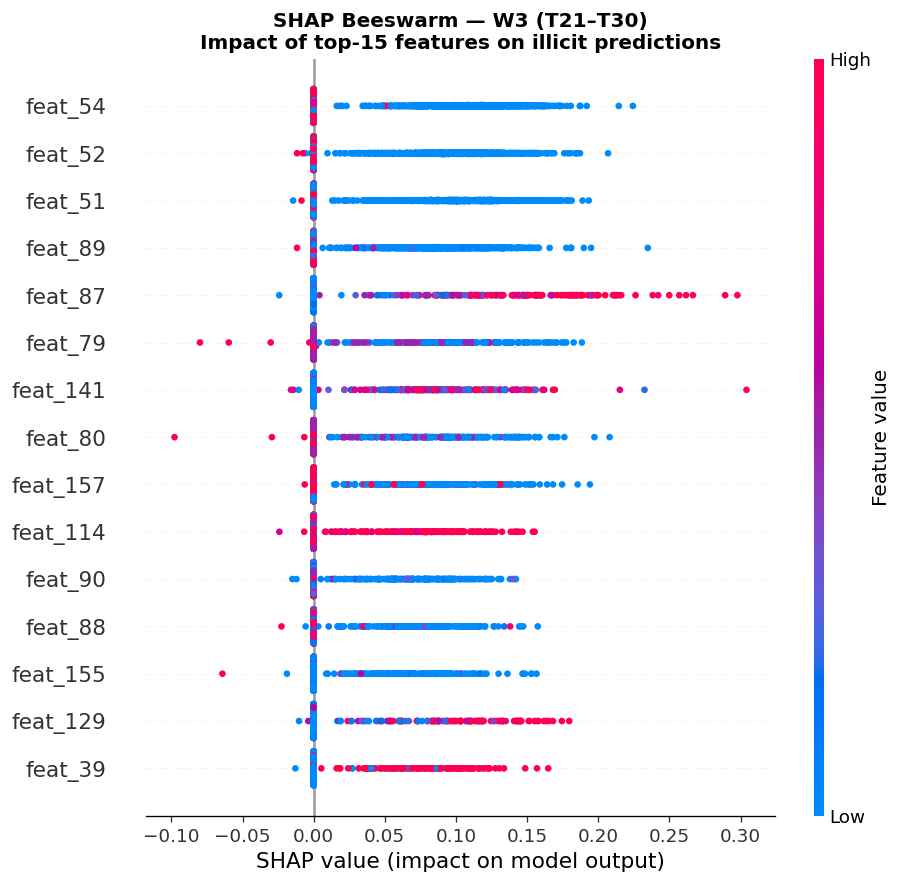

Saved → /content/drive/MyDrive/Capstone/AML Code/figures/shap_beeswarm_W3.png


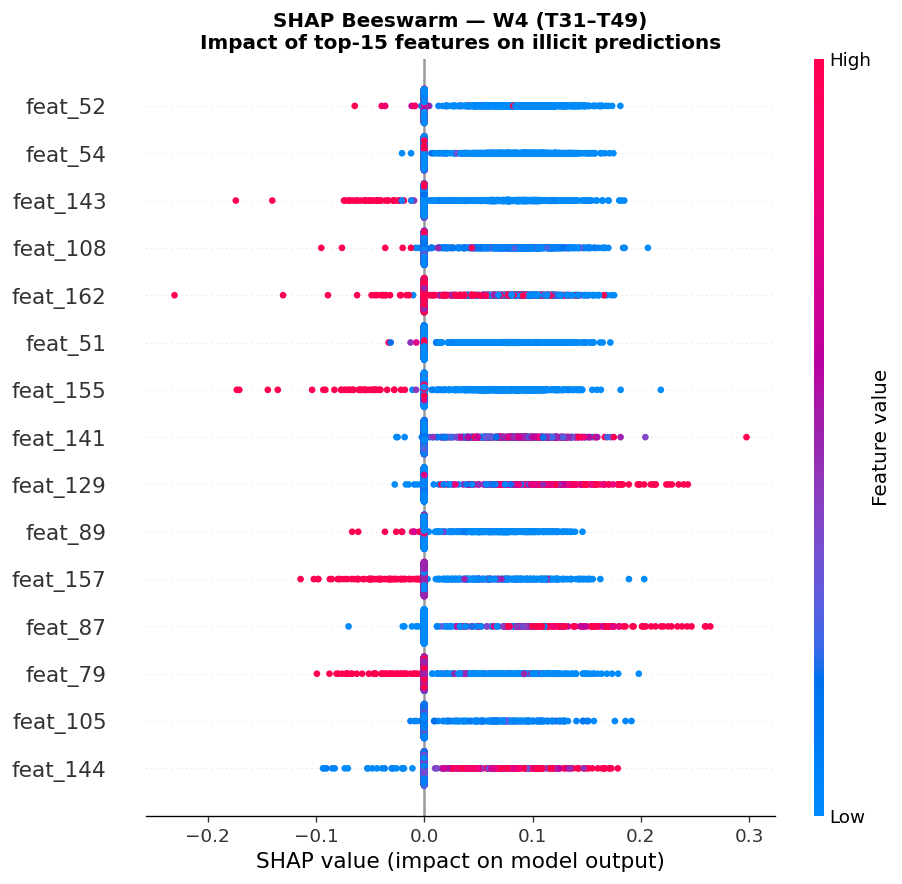

Saved → /content/drive/MyDrive/Capstone/AML Code/figures/shap_beeswarm_W4.png


In [ ]:
import shap
import matplotlib.pyplot as plt

# ── Beeswarm plots for each window ────────────────────────────────────────────
for window_name, res in shap_results.items():
    shap_vals  = res['shap_values']   # shape: (n_illicit_sampled, 165)
    X_illicit  = res['X_illicit']     # shape: (n_illicit_sampled, 165)
    time_range = res['time_range']

    # Only plot top 15 features for readability
    top15_idx   = res['ranked_idx'][:15]
    shap_top15  = shap_vals[:, top15_idx]
    X_top15     = X_illicit[:, top15_idx]
    feat_names  = [f'feat_{i}' for i in top15_idx]

    # Build SHAP Explanation object
    explanation = shap.Explanation(
        values          = shap_top15,
        data            = X_top15,
        feature_names   = feat_names,
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    shap.plots.beeswarm(explanation, max_display=15, show=False)
    plt.title(f'SHAP Beeswarm — {window_name} ({time_range})\n'
              f'Impact of top-15 features on illicit predictions',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    out_path = os.path.join(FIGURES_DIR, f'shap_beeswarm_{window_name}.png')
    plt.savefig(out_path, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved → {out_path}')

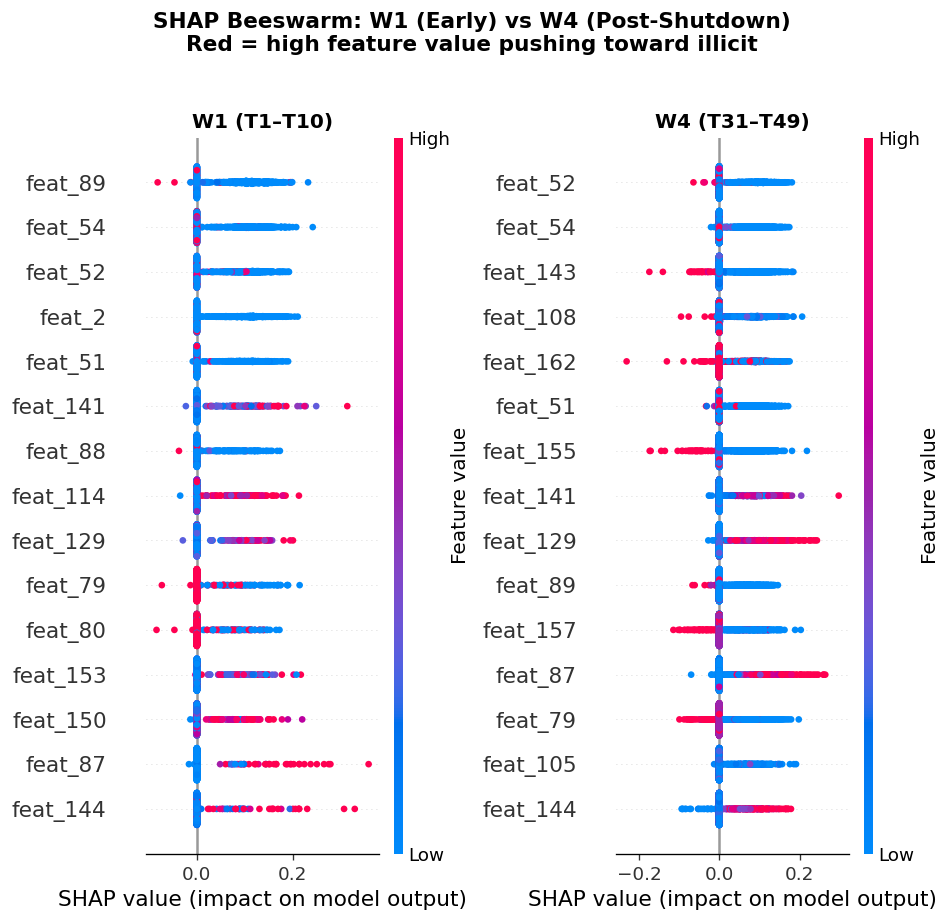

Saved → /content/drive/MyDrive/Capstone/AML Code/figures/shap_beeswarm_w1_vs_w4.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, window_name, in zip(axes, ['W1', 'W4']):
    res        = shap_results[window_name]
    shap_vals  = res['shap_values']
    X_illicit  = res['X_illicit']
    top15_idx  = res['ranked_idx'][:15]
    feat_names = [f'feat_{i}' for i in top15_idx]

    explanation = shap.Explanation(
        values        = shap_vals[:, top15_idx],
        data          = X_illicit[:, top15_idx],
        feature_names = feat_names,
    )

    plt.sca(ax)
    shap.plots.beeswarm(explanation, max_display=15, show=False)
    ax.set_title(f'{window_name} ({res["time_range"]})',
                 fontsize=12, fontweight='bold')

plt.suptitle('SHAP Beeswarm: W1 (Early) vs W4 (Post-Shutdown)\n'
             'Red = high feature value pushing toward illicit',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'shap_beeswarm_w1_vs_w4.png')
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

---
## Cell 9 — Compute Kendall τ Between Consecutive Windows

In [ ]:
# window_names = list(shap_results.keys())   # ['W1', 'W2', 'W3', 'W4']

# tau_results = []

# print('KENDALL τ RANK CORRELATION — CONSECUTIVE WINDOWS')
# print('=' * 55)
# print(f'  Using top-{TOP_K} feature rankings per window')
# print(f'  Drift threshold: τ < {TAU_THRESHOLD}')
# print()
# print(f'  {"Comparison":<12} {"τ":>8}  {"p-value":>10}  {"Status"}')
# print(f'  {"-"*50}')

# for i in range(len(window_names) - 1):
#     w_curr = window_names[i]
#     w_next = window_names[i + 1]

#     # Full importance vectors (all 165 features) for rank correlation
#     imp_curr = shap_results[w_curr]['importance']
#     imp_next = shap_results[w_next]['importance']

#     # Rank both (higher importance = lower rank number)
#     rank_curr = np.argsort(np.argsort(-imp_curr))  # descending rank
#     rank_next = np.argsort(np.argsort(-imp_next))

#     tau, pval = kendalltau(rank_curr, rank_next)

#     drift_flag = '🚨 DRIFT FLAGGED' if tau < TAU_THRESHOLD else '✓ stable'

#     print(f'  {w_curr}→{w_next:<8} {tau:>8.4f}  {pval:>10.4f}  {drift_flag}')

#     tau_results.append({
#         'comparison': f'{w_curr}→{w_next}',
#         'tau'       : round(float(tau), 4),
#         'pval'      : round(float(pval), 6),
#         'drift'     : bool(tau < TAU_THRESHOLD),
#     })

# print()
# print(f'  Threshold: τ < {TAU_THRESHOLD} = drift flagged')

# # Save tau results
# tau_path = os.path.join(SHAP_DIR, 'kendall_tau_results.json')
# with open(tau_path, 'w') as f:
#     json.dump(tau_results, f, indent=2)
# print(f'\nKendall τ results saved → {tau_path}')

window_names = list(shap_results.keys())
tau_results  = []

TOP_K_TAU = 15   # compute τ only on top-15 features per window

print('KENDALL τ RANK CORRELATION — CONSECUTIVE WINDOWS')
print('=' * 55)
print(f'  Using top-{TOP_K_TAU} feature rankings per window')
print(f'  Drift threshold: τ < {TAU_THRESHOLD}')
print()
print(f'  {"Comparison":<12} {"τ":>8}  {"p-value":>10}  {"Status"}')
print(f'  {"-"*50}')

for i in range(len(window_names) - 1):
    w_curr = window_names[i]
    w_next = window_names[i + 1]

    # Get top-K feature indices for each window
    top_curr = set(shap_results[w_curr]['ranked_idx'][:TOP_K_TAU])
    top_next = set(shap_results[w_next]['ranked_idx'][:TOP_K_TAU])

    # Union of top features from both windows
    union_features = sorted(top_curr | top_next)

    # Get importance values for only those features
    imp_curr = shap_results[w_curr]['importance'][union_features]
    imp_next = shap_results[w_next]['importance'][union_features]

    # Rank within this subset
    rank_curr = np.argsort(np.argsort(-imp_curr))
    rank_next = np.argsort(np.argsort(-imp_next))

    tau, pval = kendalltau(rank_curr, rank_next)

    drift_flag = '🚨 DRIFT FLAGGED' if tau < TAU_THRESHOLD else '✓  stable'

    print(f'  {w_curr}→{w_next:<8} {tau:>8.4f}  {pval:>10.4f}  {drift_flag}')

    tau_results.append({
        'comparison': f'{w_curr}→{w_next}',
        'tau'       : round(float(tau), 4),
        'pval'      : round(float(pval), 6),
        'drift'     : bool(tau < TAU_THRESHOLD),
    })

print()
print(f'  Threshold: τ < {TAU_THRESHOLD} = drift flagged')
print(f'  Computed on union of top-{TOP_K_TAU} features per window pair')

tau_path = os.path.join(SHAP_DIR, 'kendall_tau_results.json')
with open(tau_path, 'w') as f:
    json.dump(tau_results, f, indent=2)
print(f'\nKendall τ results saved → {tau_path}')


KENDALL τ RANK CORRELATION — CONSECUTIVE WINDOWS
  Using top-15 feature rankings per window
  Drift threshold: τ < 0.7

  Comparison          τ     p-value  Status
  --------------------------------------------------
  W1→W2         0.5556      0.0009  🚨 DRIFT FLAGGED
  W2→W3         0.5882      0.0006  🚨 DRIFT FLAGGED
  W3→W4         0.1474      0.3859  🚨 DRIFT FLAGGED

  Threshold: τ < 0.7 = drift flagged
  Computed on union of top-15 features per window pair

Kendall τ results saved → /content/drive/MyDrive/Capstone/AML Code/data/shap/kendall_tau_results.json


---
## Cell 10 — Kendall τ Plot

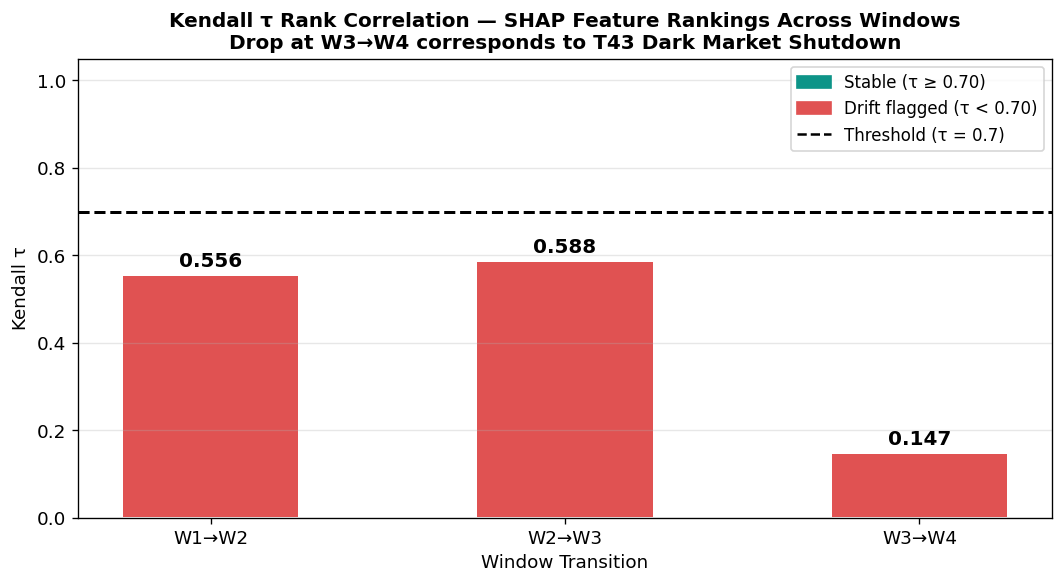

Saved → /content/drive/MyDrive/Capstone/AML Code/figures/kendall_tau_drift.png


In [ ]:
comparisons = [r['comparison'] for r in tau_results]
taus        = [r['tau']        for r in tau_results]
colors      = ['#E05252' if r['drift'] else '#0D9488' for r in tau_results]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(comparisons, taus, color=colors, width=0.5, edgecolor='white', linewidth=1.2)

# Threshold line
ax.axhline(y=TAU_THRESHOLD, color='black', linestyle='--', linewidth=1.8,
           label=f'Drift threshold (τ = {TAU_THRESHOLD})')

# Value labels on bars
for bar, tau_val in zip(bars, taus):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{tau_val:.3f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Annotations
from matplotlib.patches import Patch
legend_handles = [
    Patch(color='#0D9488', label='Stable (τ ≥ 0.70)'),
    Patch(color='#E05252', label='Drift flagged (τ < 0.70)'),
    plt.Line2D([0], [0], color='black', linestyle='--', label=f'Threshold (τ = {TAU_THRESHOLD})')
]
ax.legend(handles=legend_handles, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title('Kendall τ Rank Correlation — SHAP Feature Rankings Across Windows\n'
             'Drop at W3→W4 corresponds to T43 Dark Market Shutdown',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Window Transition', fontsize=11)
ax.set_ylabel('Kendall τ', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'kendall_tau_drift.png')
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

---
## Cell 11 — SHAP Bar Charts: W1 vs W4 Side by Side

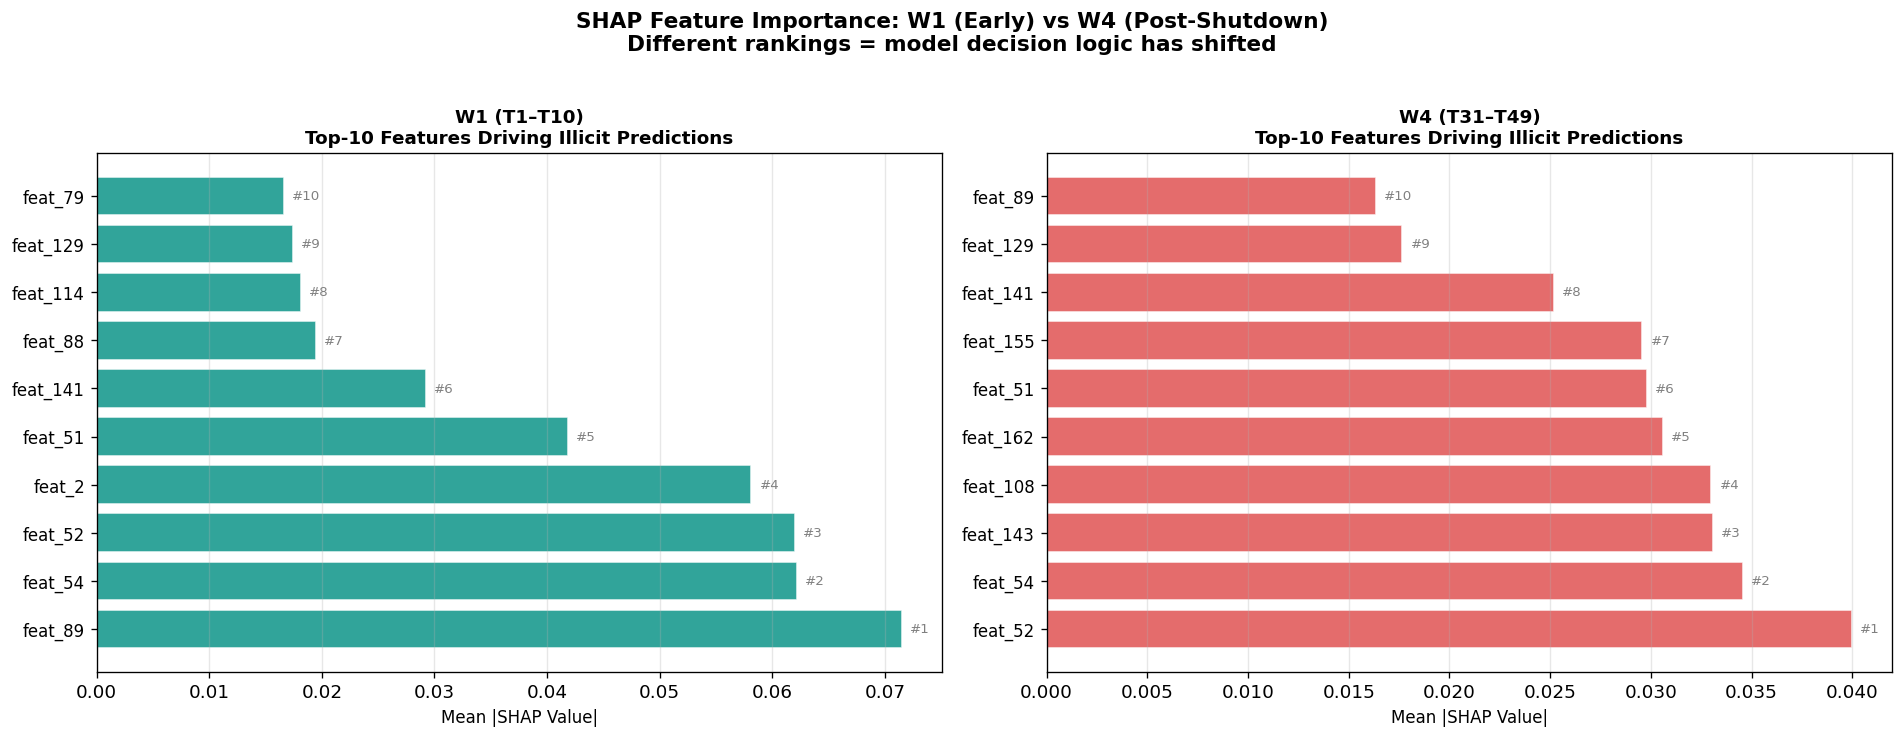

Saved → /content/drive/MyDrive/Capstone/AML Code/figures/shap_w1_vs_w4.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, window_name, color in [
    (axes[0], 'W1', '#0D9488'),
    (axes[1], 'W4', '#E05252'),
]:
    res      = shap_results[window_name]
    top_feat = res['top10_names']
    top_vals = res['top10_vals']

    # Plot horizontal bars (most important at top)
    y_pos = range(TOP_K - 1, -1, -1)
    ax.barh(list(y_pos), top_vals[::-1], color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(top_feat[::-1], fontsize=10)
    ax.set_xlabel('Mean |SHAP Value|', fontsize=10)
    ax.set_title(f'{window_name} ({res["time_range"]})\nTop-10 Features Driving Illicit Predictions',
                 fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # Rank labels
    for rank, (y, val) in enumerate(zip(y_pos, top_vals[::-1]), start=1):
        ax.text(val + max(top_vals)*0.01, y, f'#{TOP_K - rank + 1}',
                va='center', fontsize=8, color='gray')

plt.suptitle('SHAP Feature Importance: W1 (Early) vs W4 (Post-Shutdown)\n'
             'Different rankings = model decision logic has shifted',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'shap_w1_vs_w4.png')
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

---
## Cell 12 — SHAP Heatmap Across All 4 Windows

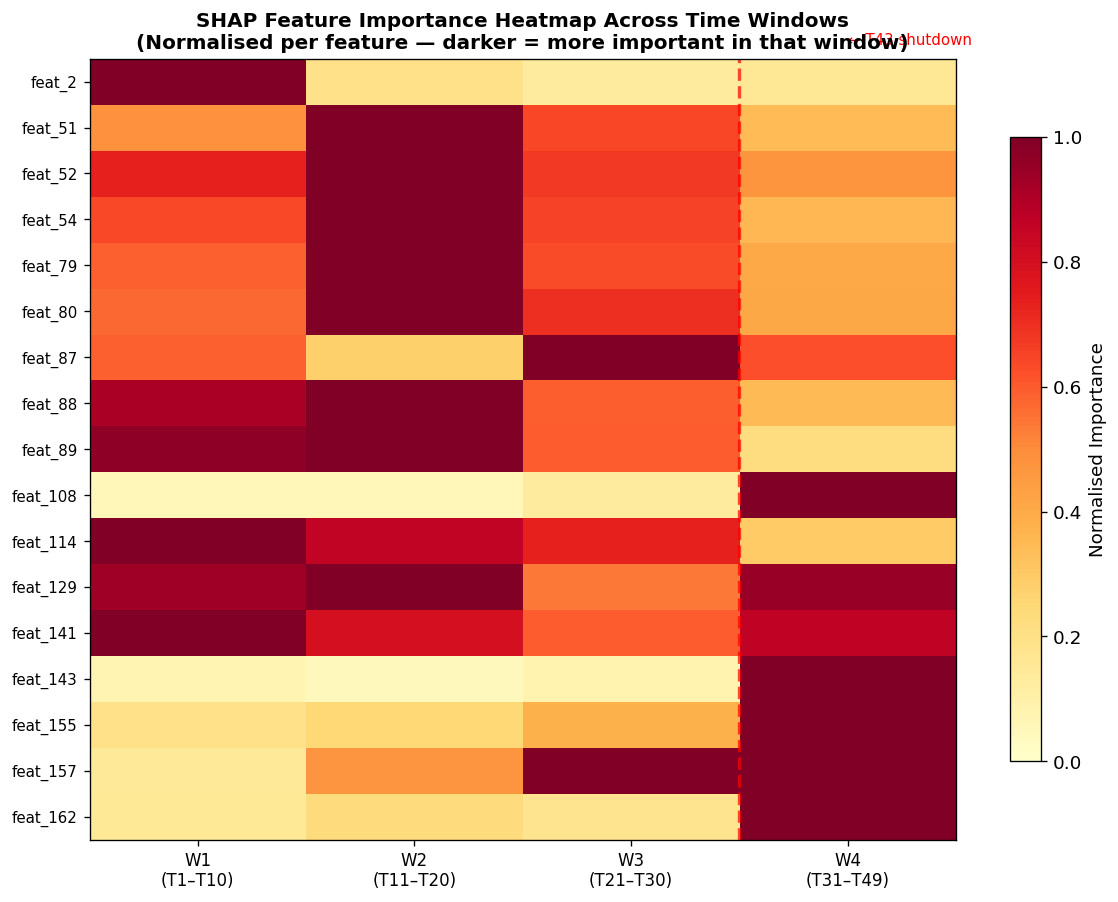

Saved → /content/drive/MyDrive/Capstone/AML Code/figures/shap_heatmap_all_windows.png


In [ ]:
# Find the union of top-10 features across all windows
all_top_features = set()
for res in shap_results.values():
    all_top_features.update(res['top10_names'])
all_top_features = sorted(all_top_features,
    key=lambda f: int(f.split('_')[1]))  # sort by feature index

# Build heatmap matrix: rows = features, cols = windows
heatmap_data = np.zeros((len(all_top_features), len(WINDOWS)))
for col, (w_name, res) in enumerate(shap_results.items()):
    for row, feat in enumerate(all_top_features):
        feat_idx = int(feat.split('_')[1])
        heatmap_data[row, col] = res['importance'][feat_idx]

# Normalise each row to 0–1 for visual clarity
row_max = heatmap_data.max(axis=1, keepdims=True)
row_max[row_max == 0] = 1
heatmap_norm = heatmap_data / row_max

fig, ax = plt.subplots(figsize=(10, max(6, len(all_top_features) * 0.45)))
im = ax.imshow(heatmap_norm, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)

ax.set_xticks(range(len(WINDOWS)))
ax.set_xticklabels(
    [f'{w}\n({res["time_range"]})' for w, res in shap_results.items()],
    fontsize=10
)
ax.set_yticks(range(len(all_top_features)))
ax.set_yticklabels(all_top_features, fontsize=9)
ax.set_title('SHAP Feature Importance Heatmap Across Time Windows\n'
             '(Normalised per feature — darker = more important in that window)',
             fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax, label='Normalised Importance', shrink=0.8)

# Mark W4 column (contains T43)
ax.axvline(x=2.5, color='red', linewidth=2, linestyle='--', alpha=0.7)
ax.text(3.0, -0.8, '← T43 shutdown', color='red', fontsize=9, ha='left')

plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'shap_heatmap_all_windows.png')
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

---
## Cell 13 — T43 Prediction Table
Shows false negatives at the shutdown snapshot.  
Used in the demo to illustrate concept drift in action.

In [ ]:
# T43 is index 42 (0-based)
T43_IDX = 42
snap_t43 = snapshots[T43_IDX]

model.eval()
with torch.no_grad():
    logits, _ = model(snap_t43.x, snap_t43.edge_index)
    probs  = torch.softmax(logits, dim=1)
    preds  = logits.argmax(dim=1)

y_true      = snap_t43.y.numpy()
y_pred      = preds.numpy()
confidence  = probs.numpy()
tx_ids      = snap_t43.tx_ids.numpy()

label_map = {0: 'Licit', 1: 'Illicit'}

# ── Summary stats ─────────────────────────────────────────────────────────────
illicit_mask = (y_true == 1)
n_illicit    = illicit_mask.sum()
n_correct    = ((y_pred == 1) & illicit_mask).sum()
n_missed     = ((y_pred == 0) & illicit_mask).sum()   # false negatives

print(f'SNAPSHOT T43 — PREDICTION SUMMARY')
print(f'=' * 50)
print(f'  Total nodes    : {len(y_true):,}')
print(f'  Illicit nodes  : {n_illicit}')
print(f'  Correctly flagged (TP) : {n_correct}')
print(f'  Missed (FN)            : {n_missed}  ← concept drift evidence')
print()

# ── Prediction table: all illicit nodes ──────────────────────────────────────
print('ILLICIT NODES AT T43 — WERE THEY CAUGHT?')
print(f'{"Tx ID":>12}  {"True":>8}  {"Predicted":>10}  {"Confidence":>11}  {"Result"}')
print('-' * 65)

for idx in np.where(illicit_mask)[0][:20]:   # show first 20 illicit
    true_lbl  = label_map[y_true[idx]]
    pred_lbl  = label_map[y_pred[idx]]
    conf      = confidence[idx][y_pred[idx]]  # confidence in predicted class
    result    = '✓ Caught' if y_pred[idx] == 1 else '✗ MISSED'
    print(f'{tx_ids[idx]:>12}  {true_lbl:>8}  {pred_lbl:>10}  {conf:>11.4f}  {result}')

if n_illicit > 20:
    print(f'  ... and {n_illicit - 20} more illicit nodes')

# Save table
import csv
table_path = os.path.join(SHAP_DIR, 't43_predictions.csv')
with open(table_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['tx_id', 'true_label', 'predicted', 'conf_licit', 'conf_illicit', 'result'])
    for idx in np.where(illicit_mask)[0]:
        result = 'Caught' if y_pred[idx] == 1 else 'Missed'
        writer.writerow([
            tx_ids[idx],
            label_map[y_true[idx]],
            label_map[y_pred[idx]],
            round(float(confidence[idx][0]), 4),
            round(float(confidence[idx][1]), 4),
            result
        ])
print(f'\nFull table saved → {table_path}')

SNAPSHOT T43 — PREDICTION SUMMARY
  Total nodes    : 1,370
  Illicit nodes  : 24
  Correctly flagged (TP) : 1
  Missed (FN)            : 23  ← concept drift evidence

ILLICIT NODES AT T43 — WERE THEY CAUGHT?
       Tx ID      True   Predicted   Confidence  Result
-----------------------------------------------------------------
    94340906   Illicit       Licit       0.6876  ✗ MISSED
    94940927   Illicit       Licit       0.9609  ✗ MISSED
    94626460   Illicit       Licit       0.6395  ✗ MISSED
    94153016   Illicit       Licit       0.8061  ✗ MISSED
    92735262   Illicit       Licit       0.7753  ✗ MISSED
    94153268   Illicit       Licit       0.7111  ✗ MISSED
    94336035   Illicit       Licit       0.8548  ✗ MISSED
    92021053   Illicit     Illicit       0.8483  ✓ Caught
    94153275   Illicit       Licit       0.7734  ✗ MISSED
    94341464   Illicit       Licit       0.9846  ✗ MISSED
    94150348   Illicit       Licit       0.9910  ✗ MISSED
    94255570   Illicit       Lic

---
## Cell 14 — Summary of All Saved Files

In [ ]:
print('ALL OUTPUTS SAVED — DEMO READY')
print('=' * 60)
print()
print('SHAP data (data/shap/):')
for w in WINDOWS:
    p = os.path.join(SHAP_DIR, f'shap_{w}.pkl')
    size = os.path.getsize(p) / 1024 if os.path.exists(p) else 0
    print(f'  shap_{w}.pkl              {size:.0f} KB')
print(f'  kendall_tau_results.json')
print(f'  t43_predictions.csv')

print()
print('Figures (figures/):')
for fig_file in [
    'kendall_tau_drift.png',
    'shap_w1_vs_w4.png',
    'shap_heatmap_all_windows.png',
    'static_gcn_drift.png',
    'static_gcn_drift_probe.png',
    'static_gcn_training_curves.png',
]:
    p = os.path.join(FIGURES_DIR, fig_file)
    exists = '✓' if os.path.exists(p) else '✗ missing'
    print(f'  {fig_file:<42} {exists}')

print()
print('DEMO CHECKLIST:')
print('  ✓ Step 1 — T43 graph visualisation (from preprocessing notebook)')
print('  ✓ Step 2 — T43 prediction table    (t43_predictions.csv)')
print('  ✓ Step 3 — SHAP bar charts W1 vs W4 (shap_w1_vs_w4.png)')
print('  ✓ Step 4 — Kendall τ table & plot   (kendall_tau_drift.png)')
print('  ✓ Step 5 — Drift plot T37–T49       (static_gcn_drift.png)')
print()
print('Load all pre-computed results for demo:')
print("  with open('data/shap/shap_W1.pkl', 'rb') as f: w1 = pickle.load(f)")
print("  with open('data/shap/shap_W4.pkl', 'rb') as f: w4 = pickle.load(f)")
print("  with open('data/shap/kendall_tau_results.json') as f: tau = json.load(f)")

ALL OUTPUTS SAVED — DEMO READY

SHAP data (data/shap/):
  shap_W1.pkl              1016 KB
  shap_W2.pkl              2414 KB
  shap_W3.pkl              2291 KB
  shap_W4.pkl              3080 KB
  kendall_tau_results.json
  t43_predictions.csv

Figures (figures/):
  kendall_tau_drift.png                      ✓
  shap_w1_vs_w4.png                          ✓
  shap_heatmap_all_windows.png               ✓
  static_gcn_drift.png                       ✓
  static_gcn_drift_probe.png                 ✓
  static_gcn_training_curves.png             ✓

DEMO CHECKLIST:
  ✓ Step 1 — T43 graph visualisation (from preprocessing notebook)
  ✓ Step 2 — T43 prediction table    (t43_predictions.csv)
  ✓ Step 3 — SHAP bar charts W1 vs W4 (shap_w1_vs_w4.png)
  ✓ Step 4 — Kendall τ table & plot   (kendall_tau_drift.png)
  ✓ Step 5 — Drift plot T37–T49       (static_gcn_drift.png)

Load all pre-computed results for demo:
  with open('data/shap/shap_W1.pkl', 'rb') as f: w1 = pickle.load(f)
  with open('data/